<a href="https://colab.research.google.com/github/dontatrahul/News-Aggregator/blob/main/ml_impl_hardness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***Data Pre-Processing***

In [ ]:
import pandas as pd

In [ ]:
data=pd.read_excel("/content/fyp_data_h.xlsx")
print(data.head())

   traverse_speed  axial_load  rotation_speed  passes  hardness
0              90           8            1200       2     46.73
1              80           7            1200       2     45.48
2              80           8            1400       2     45.71
3              80           7            1200       2     45.48
4              70           7            1200       3     44.00


In [ ]:
print(data.columns)
print(data.shape)

Index(['traverse_speed', 'axial_load', 'rotation_speed', 'passes', 'hardness'], dtype='object')
(29, 5)


In [ ]:
X=data[["traverse_speed","axial_load","rotation_speed","passes"]]
y=data[["hardness"]].values.ravel()

In [ ]:
from sklearn import model_selection
X_train,X_test,y_train,y_test= model_selection.train_test_split(X,y,test_size=0.2, random_state = 33)

In [ ]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

    traverse_speed  axial_load  rotation_speed  passes
28              90           7            1200       3
25              80           6            1200       3
23              70           7            1200       1
0               90           8            1200       2
21              80           7            1200       2
27              90           7            1400       2
26              90           7            1000       2
12              80           7            1400       1
17              80           7            1200       2
1               80           7            1200       2
22              70           8            1200       2
13              80           6            1000       2
10              80           7            1000       1
14              80           8            1000       2
19              80           6            1200       1
6               80           7            1400       3
3               80           7            1200       2
9         

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_scaled=scaler.fit_transform(X)

In [ ]:
correlation_matrix = data.corr()
correlation_with_output = correlation_matrix['hardness']
print(correlation_with_output)

traverse_speed    0.911407
axial_load       -0.114031
rotation_speed    0.162621
passes            0.265698
hardness          1.000000
Name: hardness, dtype: float64


In [ ]:
ranked_data = data.sort_values(by='hardness')
print(ranked_data)

    traverse_speed  axial_load  rotation_speed  passes  hardness
23              70           7            1200       1     42.38
9               70           7            1000       2     42.45
22              70           8            1200       2     42.68
15              70           6            1200       2     43.24
18              70           7            1400       2     43.47
4               70           7            1200       3     44.00
10              80           7            1000       1     44.39
20              80           8            1200       1     44.62
14              80           8            1000       2     45.00
19              80           6            1200       1     45.18
13              80           6            1000       2     45.26
12              80           7            1400       1     45.41
11              80           7            1200       2     45.48
3               80           7            1200       2     45.48
17              80       

In [ ]:
print(correlation_matrix)

                traverse_speed    axial_load  rotation_speed        passes  \
traverse_speed    1.000000e+00 -3.885781e-17    1.136868e-16  1.184238e-16   
axial_load       -3.885781e-17  1.000000e+00    2.960595e-16 -9.251859e-17   
rotation_speed    1.136868e-16  2.960595e-16    1.000000e+00  2.535009e-16   
passes            1.184238e-16 -9.251859e-17    2.535009e-16  1.000000e+00   
hardness          9.114067e-01 -1.140312e-01    1.626208e-01  2.656982e-01   

                hardness  
traverse_speed  0.911407  
axial_load     -0.114031  
rotation_speed  0.162621  
passes          0.265698  
hardness        1.000000  


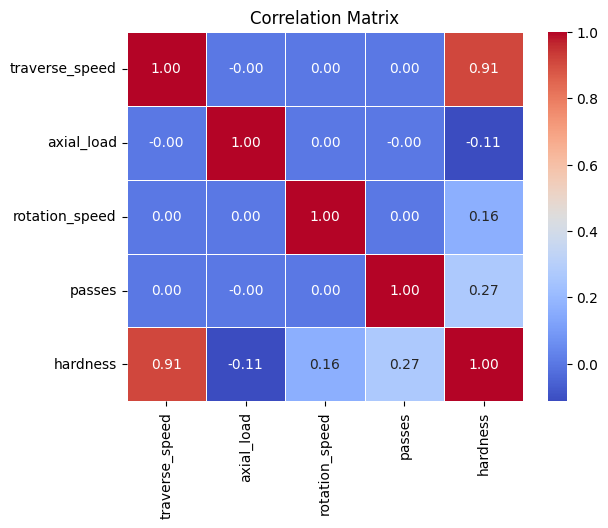

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

<ipython-input-12-ed3dd9b93049>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp,y=X.columns,palette='viridis')


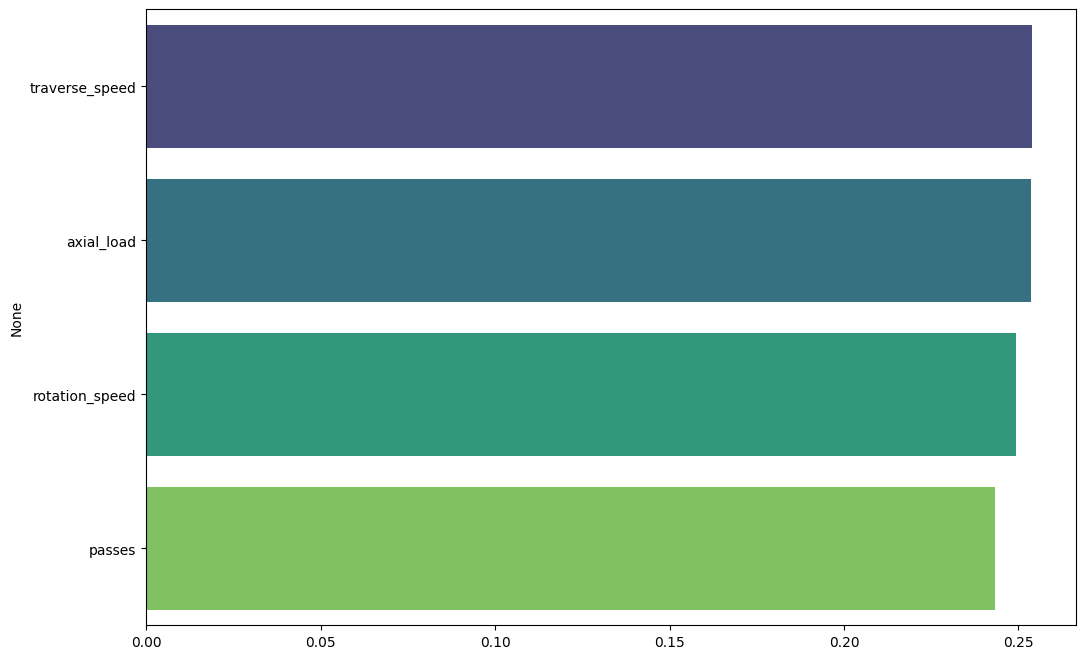

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
rfc_feature_imp=RandomForestClassifier(n_estimators=100,random_state=33)
rfc_feature_imp.fit(X,le.fit_transform(y))
feature_imp=rfc_feature_imp.feature_importances_
plt.figure(figsize=(12,8))
sns.barplot(x=feature_imp,y=X.columns,palette='viridis')
plt.show()

In [ ]:
feature_imp

array([0.25384991, 0.25360252, 0.24918555, 0.24336202])

### ***Random Forest Regression***

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
param_grid = {
    'n_estimators': np.arange(50,301,50),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
regressor_optimised=RandomForestRegressor(min_samples_leaf=1, min_samples_split=5, n_estimators=100,max_depth=None )
regressor_optimised.fit(X_train,y_train)
y_train_pred = regressor_optimised.predict(X_train)
mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", regressor_optimised.score(X_train, y_train))

Mean Squared Error: 0.4354935937800046
Mean Absolute Error: 0.449798046928922
r2 score: 0.8799424210486811


In [ ]:
y_test_pred = regressor_optimised.predict(X_test)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", regressor_optimised.score(X_test, y_test))

Mean Squared Error: 0.2014163412130724
Mean Absolute Error: 0.3395064021164072
r2 score: 0.9450489960973386


In [ ]:
print(y_train_pred)
print(y_test_pred)


[48.44482103 46.42304758 42.83264524 48.36816389 45.71322952 48.36816389
 48.3320377  45.29580139 45.71322952 45.71322952 42.85557024 45.33052123
 44.95323008 45.2206744  45.1176006  46.51425012 45.71322952 42.835625
 42.84057024 45.7985423  46.03180889 46.0295102  44.98641972]
[45.71322952 42.85974167 48.36816389 46.22546687 43.09794524 48.22213496]


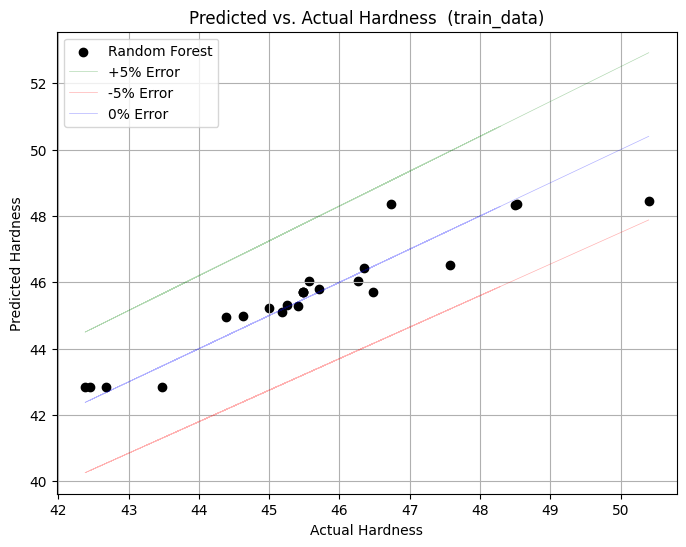

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_train, y_train_pred, label='Random Forest',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (train_data)")
plt.grid(True)
plt.legend()
plt.show()



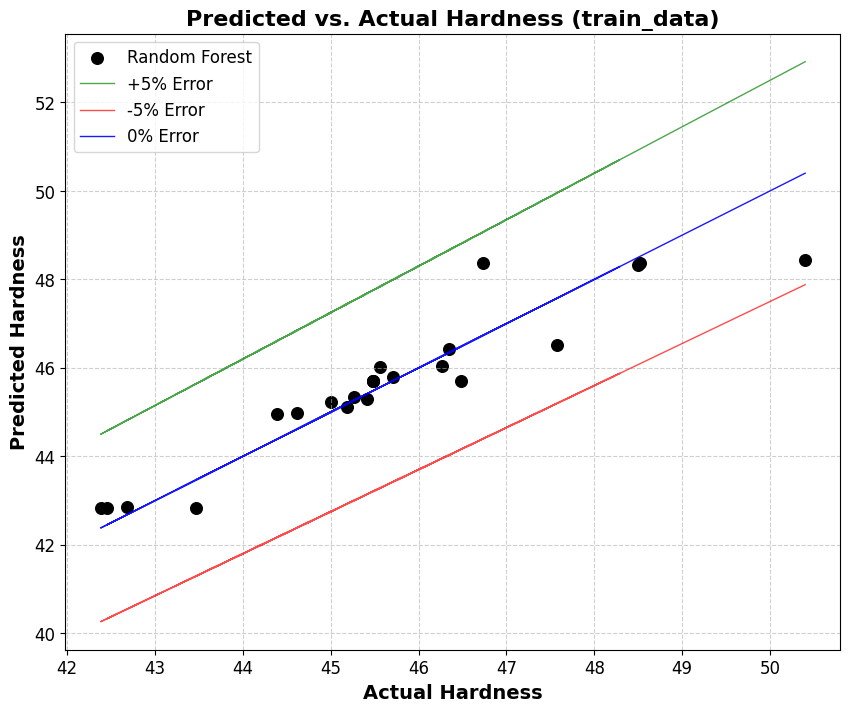

In [ ]:
plt.figure(figsize=(10, 8))  # Larger figure size
plt.scatter(y_train, y_train_pred, label='Random Forest', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (train_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Train_RF.png", dpi=300, bbox_inches='tight')  # Save as PNG

# Display the plot
plt.show()

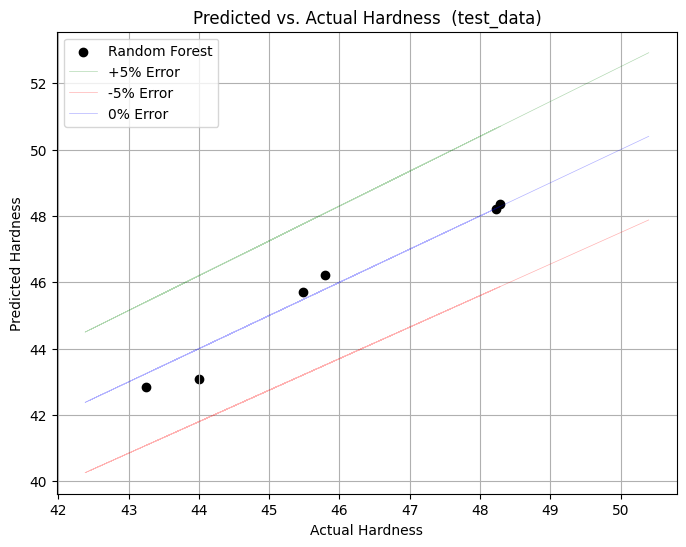

In [ ]:

upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, label='Random Forest',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (test_data)")
plt.grid(True)
plt.legend()
plt.show()

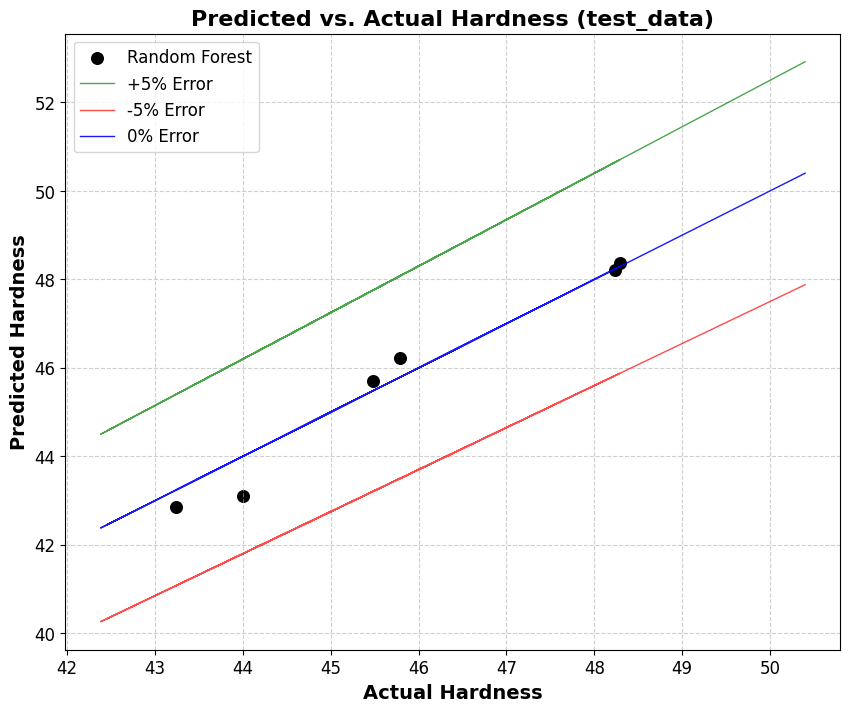

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for clarity
plt.scatter(y_test, y_test_pred, label='Random Forest', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styles
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (test_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid lines for better aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Test.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

lr_model = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'n_jobs': [1, -1],
    'copy_X': [True, False],
    'positive':[True, False]
}


In [ ]:
grid_search = GridSearchCV(lr_model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [True, False], 'n_jobs': [1, -1],
                         'positive': [True, False]},
             scoring='neg_mean_squared_error')

In [ ]:
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': 1, 'positive': True}


In [ ]:
lr_optimised=LinearRegression(copy_X= True, fit_intercept= True, n_jobs= 1, positive= False)
lr_optimised.fit(X_train_scaled,y_train)
y_train_pred = lr_optimised.predict(X_train_scaled)

mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", lr_optimised.score(X_train_scaled, y_train))

Mean Squared Error: 0.2345404662355048
Mean Absolute Error: 0.34388714852335645
r2 score: 0.9353415045719988


In [ ]:
y_test_pred = lr_optimised.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", lr_optimised.score(X_test_scaled, y_test))

Mean Squared Error: 0.35295928869564297
Mean Absolute Error: 0.4392349409258216
r2 score: 0.9037045994690323


In [ ]:
print(y_train_pred)
print(y_test_pred)

[49.23049971 46.90000581 42.12533411 48.00841081 45.67791691 48.83788931
 47.87288931 45.28530651 45.67791691 45.67791691 42.65346601 45.54239541
 44.32030651 44.84843841 45.14978501 47.03552731 45.67791691 42.51794451
 43.48294451 45.81343841 46.50739541 46.07052731 44.45582801]
[45.19541691 42.86492301 48.21986781 45.72354881 43.39305491 46.99777891]


In [ ]:
coefficients = lr_optimised.coef_
intercept = lr_optimised.intercept_
print(coefficients)
print(intercept)

[ 5.3549448 -0.693957   0.965      1.7502208]
41.989812608948284


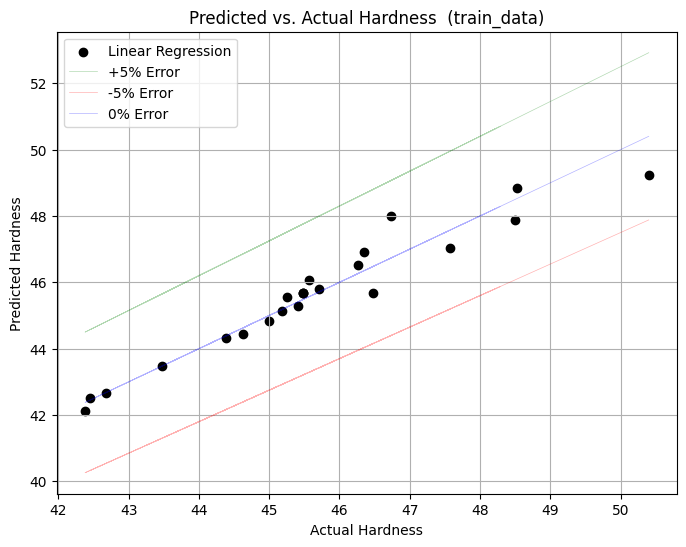

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_train, y_train_pred, label='Linear Regression',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (train_data)")
plt.grid(True)
plt.legend()
plt.show()

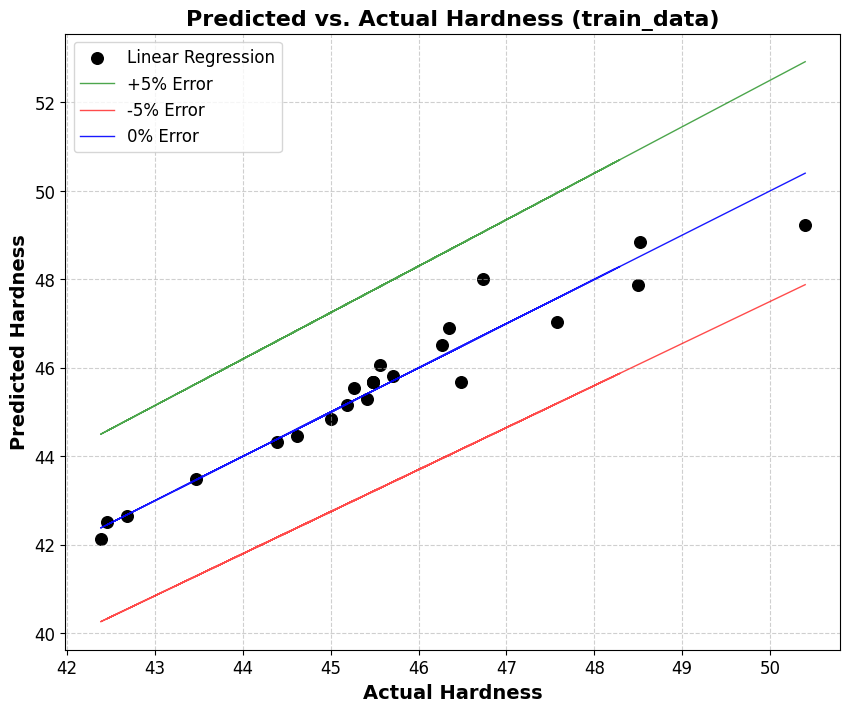

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_train, y_train_pred, label='Linear Regression', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styles
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (train_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid lines for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Train_LR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

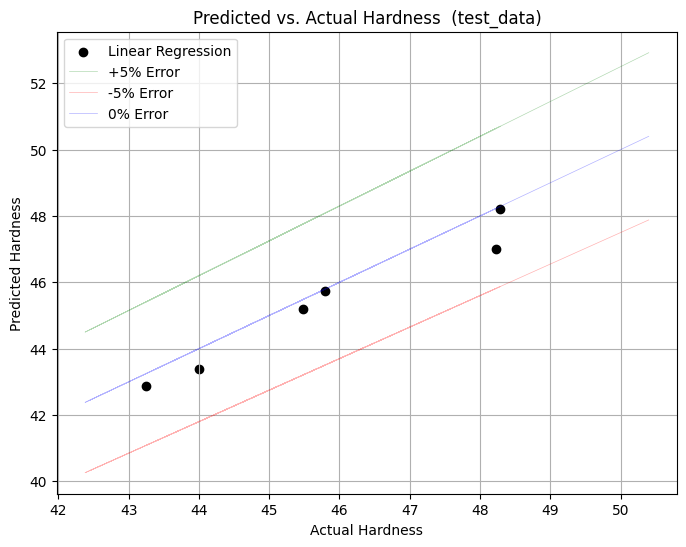

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, label='Linear Regression',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (test_data)")
plt.grid(True)
plt.legend()
plt.show()

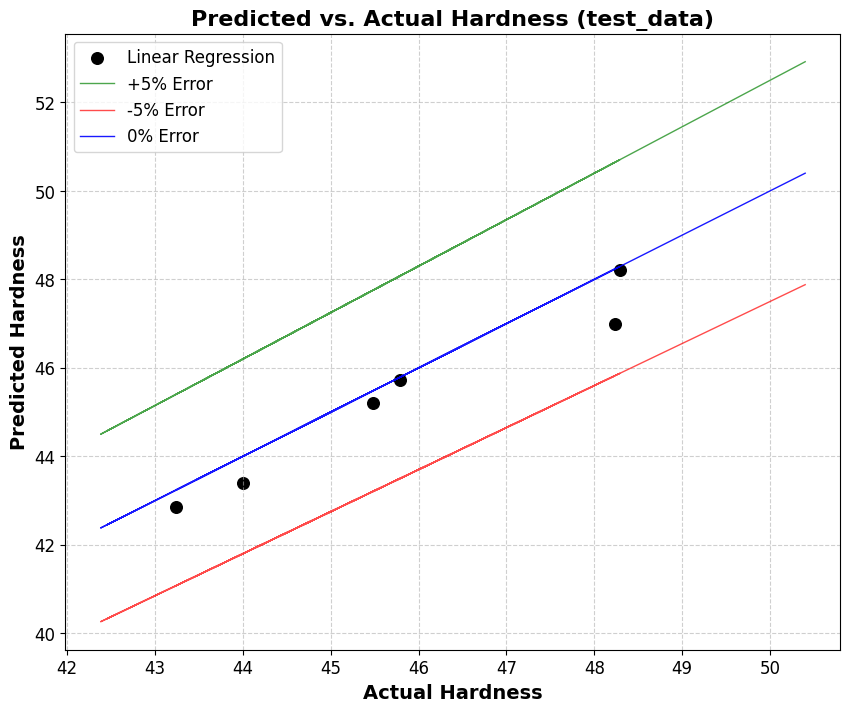

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_test, y_test_pred, label='Linear Regression', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styles
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (test_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid lines for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Test_LR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

In [ ]:
coefficients = lr_optimised.coef_
intercept = lr_optimised.intercept_
print(coefficients)
print(intercept)

[ 5.3549448 -0.693957   0.965      1.7502208]
41.989812608948284


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_optimised, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

Cross-Validation Scores: [ -5.47027111  -3.48905658 -10.5045524   -6.30685473  -5.648185  ]
Mean CV Score: -6.283783963006317


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
svm_model = SVR()
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}


In [ ]:
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'C': 0.1, 'epsilon': 0.5, 'kernel': 'poly'}


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
svm_optimised = SVR(C= 10, epsilon= 0.1, kernel= 'linear')
svm_optimised.fit(X_train_scaled,y_train)
y_train_pred = svm_optimised.predict(X_train_scaled)

mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", svm_optimised.score(X_train_scaled, y_train))

Mean Squared Error: 0.2781807291620311
Mean Absolute Error: 0.29744901614529373
r2 score: 0.9233106862394461


In [ ]:
y_test_pred = svm_optimised.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("r2 score:", svm_optimised.score(X_test_scaled, y_test))

Mean Squared Error: 0.4279387245123481
Mean Absolute Error: 0.568645521084799
r2 score: 0.883248487291796


In [ ]:
print(y_train_pred)
print(y_test_pred)

[48.80062479 46.45007779 42.35859484 47.93015682 45.57960982 48.60964934
 47.69964934 45.38863436 45.57960982 45.57960982 42.78007779 45.34910233
 44.47863436 44.9001173  45.15812687 46.68058527 45.57960982 42.5495703
 43.4595703  45.8101173  46.25910233 45.77058527 44.70914185]
[45.12460982 42.77406281 47.92414185 45.54609276 43.19554576 47.05367388]


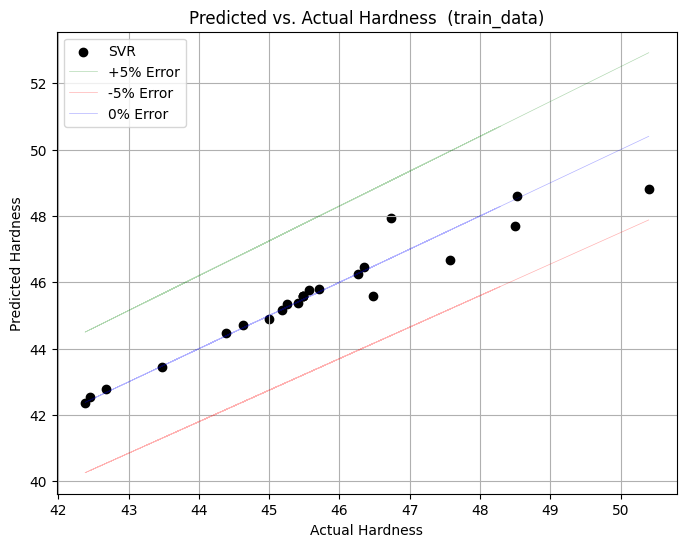

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_train, y_train_pred, label='SVR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (train_data)")
plt.grid(True)
plt.legend()
plt.show()

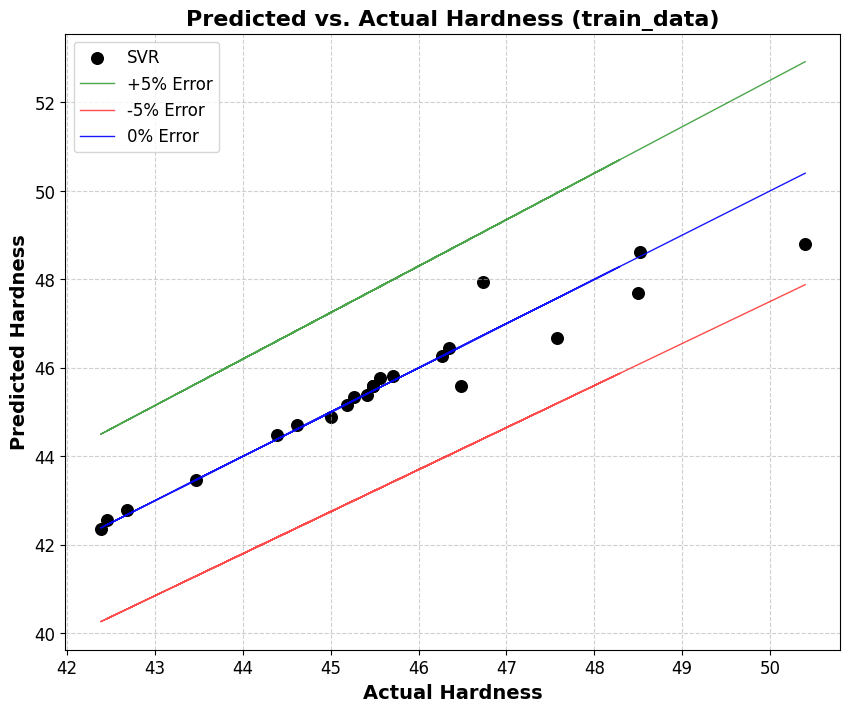

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for clarity
plt.scatter(y_train, y_train_pred, label='SVR', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styling
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (train_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Train_SVR.png", dpi=300, bbox_inches='tight')  # High-quality PNG save

# Display the plot
plt.show()

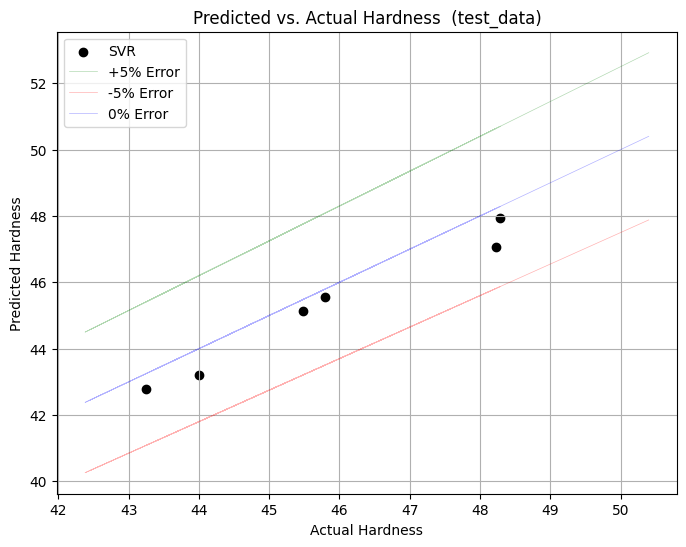

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, label='SVR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (test_data)")
plt.grid(True)
plt.legend()
plt.show()

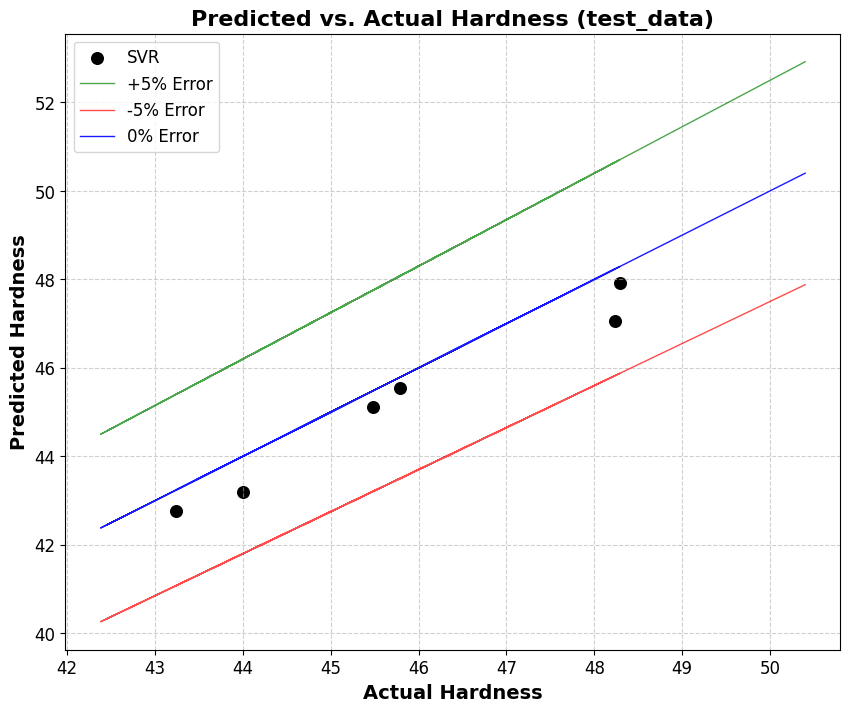

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_test, y_test_pred, label='SVR', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styles
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (test_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid lines for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Test_SVR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_optimised, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

Cross-Validation Scores: [-6.3373364  -1.49141889 -9.42840043 -3.12179276 -3.60485075]
Mean CV Score: -4.796759843771541


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
dt_regressor = DecisionTreeRegressor(max_depth=5, min_samples_leaf= 1, min_samples_split= 5)
dt_regressor.fit(X_train,y_train)
y_train_pred = dt_regressor.predict(X_train)
mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.4889728260869563
Mean Absolute Error (MAE): 0.4957246376811596
R-squared (R2): 0.8651991797090824


In [ ]:
y_test_pred = dt_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.43064745370370355
Mean Absolute Error (MAE): 0.557500000000001
R-squared (R2): 0.8825094837557921


In [ ]:
print(y_train_pred)
print(y_test_pred)

[48.5375     46.49333333 42.745      48.5375     45.81666667 48.5375
 48.5375     44.9        45.81666667 45.81666667 42.745      45.13
 44.9        45.13       44.9        46.49333333 45.81666667 42.745
 42.745      45.81666667 45.81666667 46.49333333 44.9       ]
[45.81666667 42.745      48.5375     46.49333333 42.745      48.5375    ]


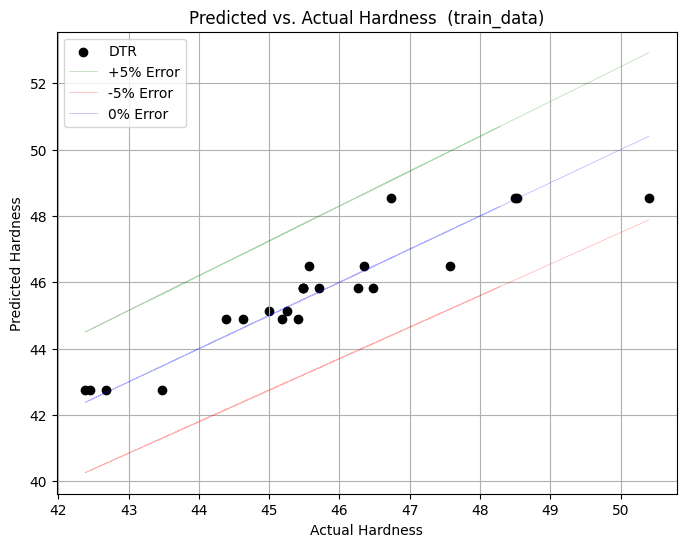

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_train, y_train_pred, label='DTR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (train_data)")
plt.grid(True)
plt.legend()
plt.show()

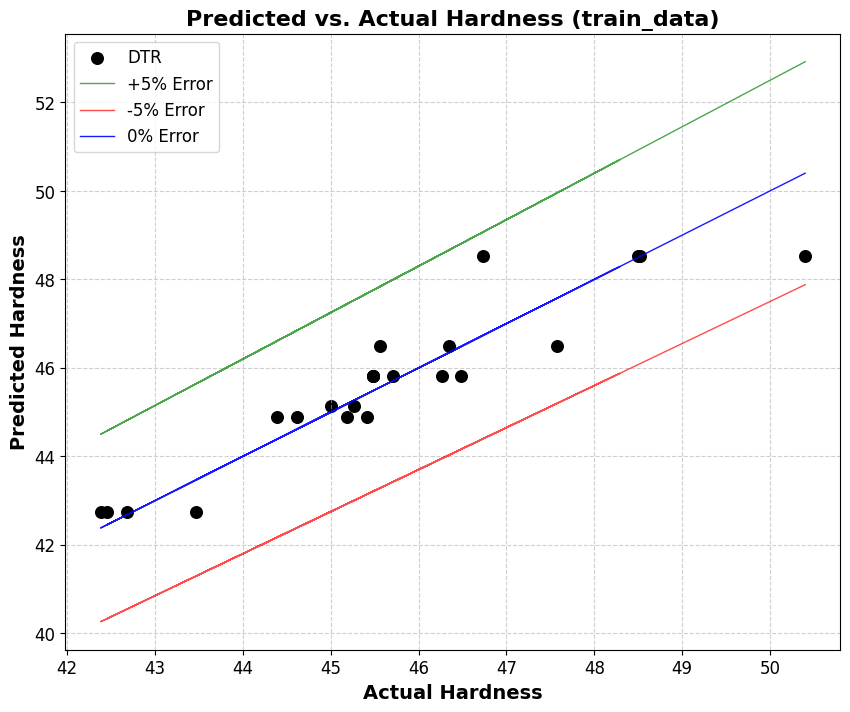

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_train, y_train_pred, label='DTR', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styling
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (train_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Train_DTR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

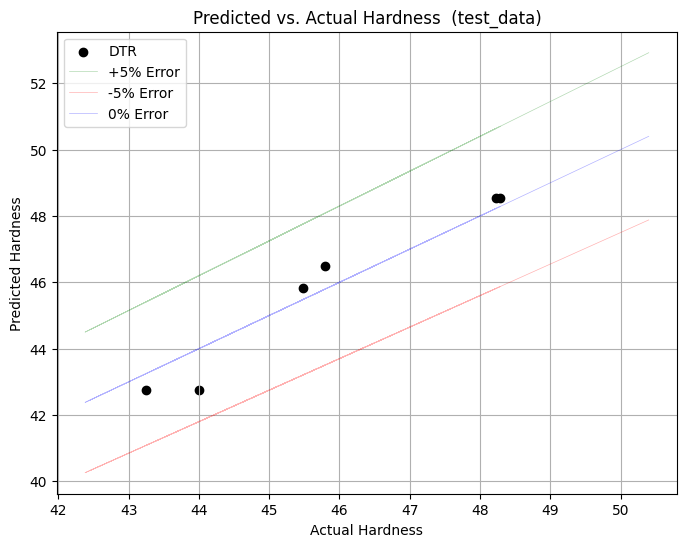

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, label='DTR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (test_data)")
plt.grid(True)
plt.legend()
plt.show()

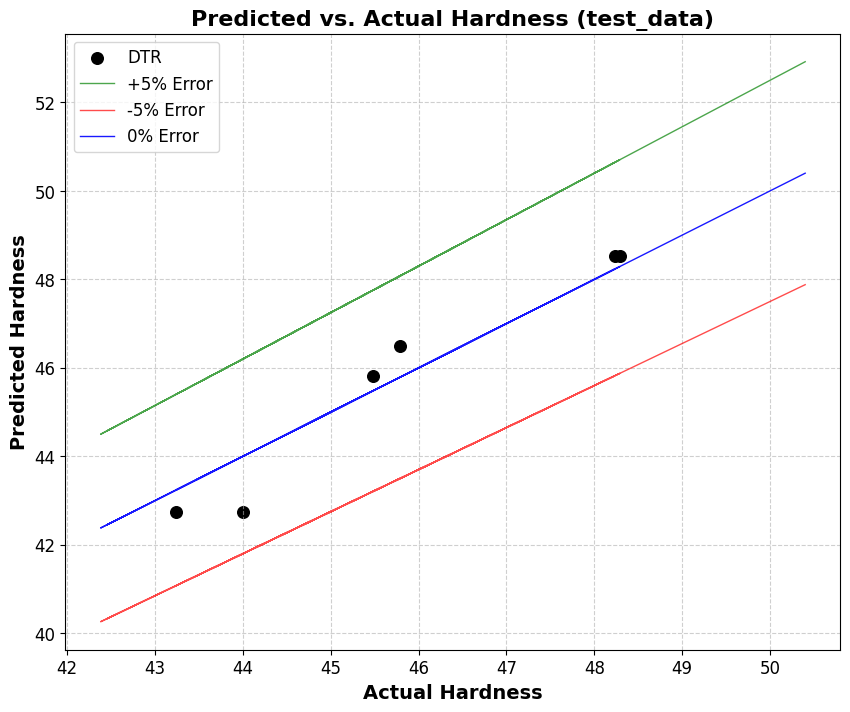

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_test, y_test_pred, label='DTR', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styling
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (test_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Test_DTR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

GBR

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


NameError: name 'GridSearchCV' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
grb_optimised=GradientBoostingRegressor(learning_rate= 0.2,max_depth= 3, n_estimators= 50,random_state=42)
grb_optimised.fit(X_train, y_train)

y_train_pred = grb_optimised.predict(X_train)
mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.03294505111764259
Mean Absolute Error (MAE): 0.07590512092362467
R-squared (R2): 0.9909176549733366


In [ ]:
y_test_pred = grb_optimised.predict(X_test)
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 0.23683108126954708
Mean Absolute Error (MAE): 0.4179208134455242
R-squared (R2): 0.9353870416236627


In [ ]:
print(y_train_pred)
print(y_test_pred)


[50.39198579 46.36159705 42.38231218 46.73001649 45.72707703 48.56204223
 48.46152685 45.4181143  45.72707703 45.72707703 42.68094353 45.27358996
 44.38917215 44.99653834 45.17894762 47.5238342  45.72707703 42.4490311
 43.47600983 45.71801179 46.24897803 45.59608042 44.62296001]
[45.72707703 42.72990267 48.62801514 46.06476187 43.06861493 48.02381156]


In [ ]:
import numpy as np

In [ ]:
new_data = np.array([80, 7, 1100, 3]).reshape(1, -1)  # Reshape for single sample
new_data_scaled = scaler.transform(new_data)
predicted_hardness = grb_optimised.predict(new_data_scaled)

new_data_scaled

Predicted Hardness: [42.73670921]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


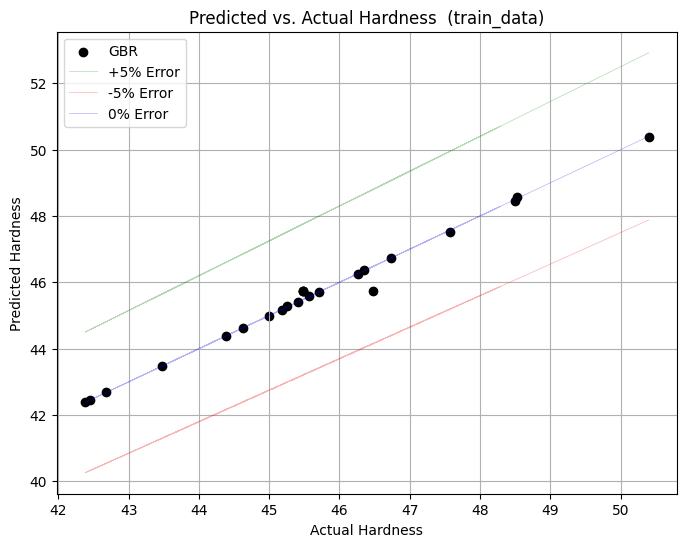

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_train, y_train_pred, label='GBR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (train_data)")
plt.grid(True)
plt.legend()
plt.show()

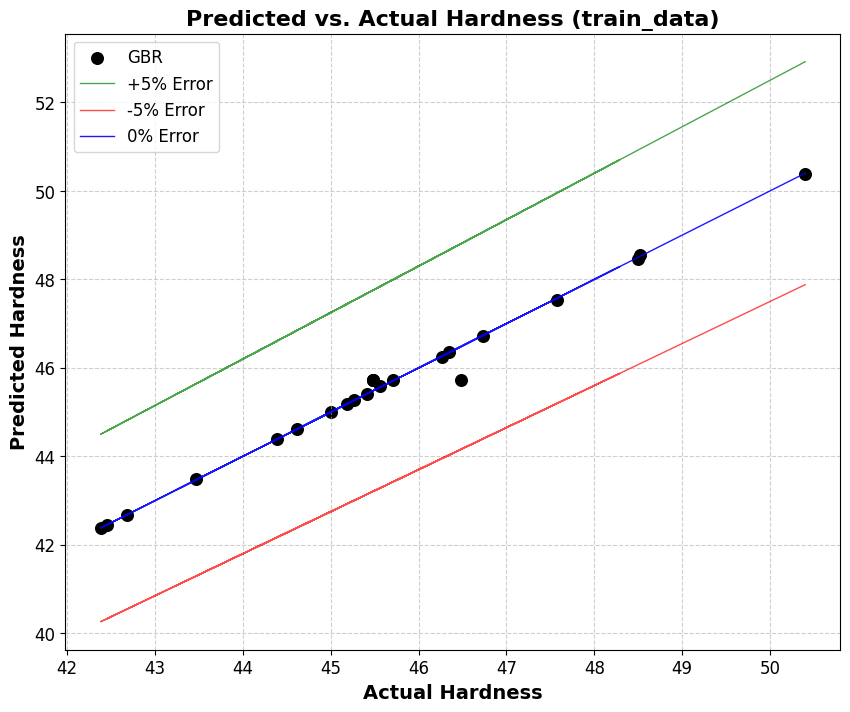

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_train, y_train_pred, label='GBR', color="black", s=70)  # Larger scatter points
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced line styling
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (train_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Train_GBR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()

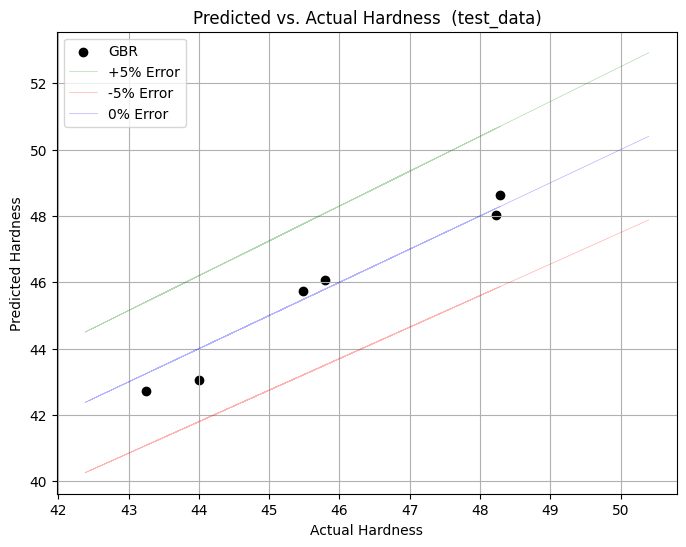

In [ ]:
import matplotlib.pyplot as plt


upper_bound = y * 1.05
lower_bound = y * 0.95


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, label='GBR',color="black")
plt.plot(y, upper_bound, color='green', label='+5% Error',alpha=0.3,linewidth=0.5)
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.3,linewidth=0.5)
plt.plot(y,y, color='blue', label='0% Error', alpha=0.3,linewidth=0.5)
plt.xlabel("Actual Hardness")
plt.ylabel("Predicted Hardness")
plt.title("Predicted vs. Actual Hardness  (test_data)")
plt.grid(True)
plt.legend()
plt.show()

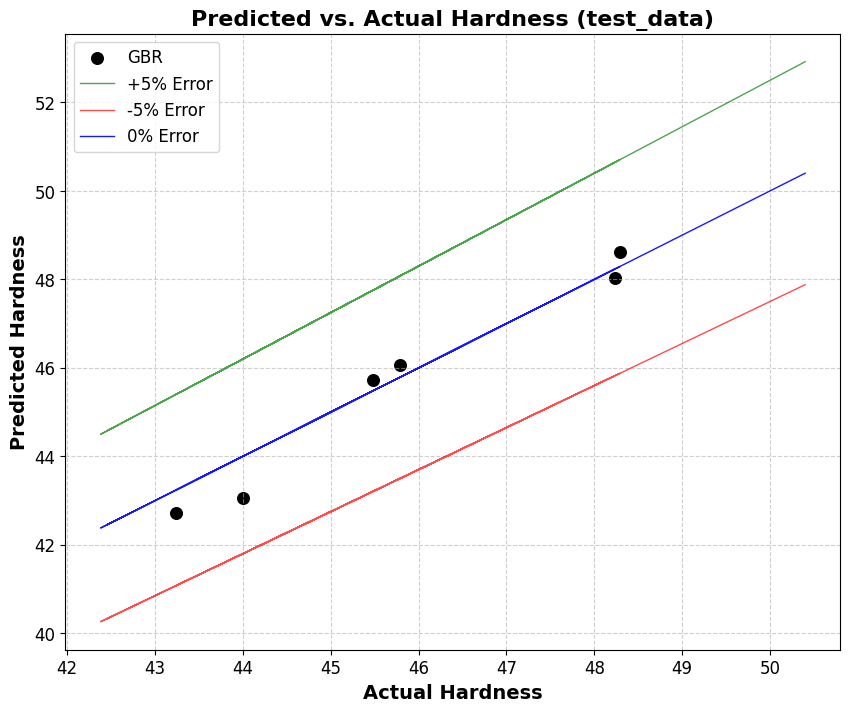

In [ ]:
plt.figure(figsize=(10, 8))  # Increased figure size for better clarity
plt.scatter(y_test, y_test_pred, label='GBR', color="black", s=70)  # Larger scatter points for visibility
plt.plot(y, upper_bound, color='green', label='+5% Error', alpha=0.7, linewidth=1)  # Enhanced styling for error bounds
plt.plot(y, lower_bound, color='red', label='-5% Error', alpha=0.7, linewidth=1)
plt.plot(y, y, color='blue', label='0% Error', alpha=0.9, linewidth=1)

# Customize labels and title
plt.xlabel("Actual Hardness", fontsize=14, weight='bold')
plt.ylabel("Predicted Hardness", fontsize=14, weight='bold')
plt.title("Predicted vs. Actual Hardness (test_data)", fontsize=16, weight='bold')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)  # Dashed grid for aesthetics
plt.legend(fontsize=12, loc='upper left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot in high resolution
plt.savefig("Predicted_vs_Actual_Hardness_Test_GBR.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG

# Display the plot
plt.show()